In [13]:
import os
import pandas as pd
from pathlib import Path

project_root = Path(os.getcwd()).resolve().parent
data_path = project_root / "data" / "processed" / "crime_data_processed.csv"
df = pd.read_csv(data_path)

df["Crime Count"] = pd.to_numeric(df["Crime Count"], errors="coerce")

# Aggregate to State-Year-Month level
cluster_df = (
    df.groupby(["State", "Year", "Month"])
    .agg(
        total_crime=("Crime Count", "sum"),
        unique_crimes=("Crime Description", "nunique"),
    )
    .reset_index()
)

print(cluster_df.head())

            State  Year  Month  total_crime  unique_crimes
0  Andhra Pradesh  2020      1         14.0             12
1  Andhra Pradesh  2020      2          8.0              7
2  Andhra Pradesh  2020      3         14.0              8
3  Andhra Pradesh  2020      4          7.0              7
4  Andhra Pradesh  2020      5         18.0             11


Adding Cluster_id to original dataset


In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ["total_crime", "unique_crimes"]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df[features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# cluster -> State | Year | Month | total_crime | unique_crimes | Cluster_ID
cluster_df["Cluster_ID"] = kmeans.fit_predict(X_cluster)
print(cluster_df.head())


save_path = project_root / "data" / "processed" / "crime_data_pred_table.csv"
save_path.parent.mkdir(parents=True, exist_ok=True)
cluster_df.to_csv(save_path, index=False)

            State  Year  Month  total_crime  unique_crimes  Cluster_ID
0  Andhra Pradesh  2020      1         14.0             12           3
1  Andhra Pradesh  2020      2          8.0              7           0
2  Andhra Pradesh  2020      3         14.0              8           0
3  Andhra Pradesh  2020      4          7.0              7           0
4  Andhra Pradesh  2020      5         18.0             11           0


In [15]:
# creating new file with cluster_id from k-means
df_with_cluster = df.merge(
    cluster_df[["State", "Year", "Month", "Cluster_ID"]],
    on=["State", "Year", "Month"],
    how="left",
)
# dataSet -> State | Year | Month | Crime Description | Crime Count | Cluster_ID
print(df_with_cluster.head())

save_path = project_root / "data" / "processed" / "crime_data_proc_cluster.csv"
save_path.parent.mkdir(parents=True, exist_ok=True)
df_with_cluster.to_csv(save_path, index=False)

            State  Year  Month  Crime Description  Crime Count  Cluster_ID
0  Andhra Pradesh  2020      1           BURGLARY          1.0           3
1  Andhra Pradesh  2020      1     COUNTERFEITING          2.0           3
2  Andhra Pradesh  2020      1         CYBERCRIME          2.0           3
3  Andhra Pradesh  2020      1  DOMESTIC VIOLENCE          1.0           3
4  Andhra Pradesh  2020      1       DRUG OFFENSE          1.0           3


Encode categorical features


In [16]:
from sklearn.preprocessing import LabelEncoder

df_model = df_with_cluster.copy()

state_encoder = LabelEncoder()
crime_encoder = LabelEncoder()

df_model["State"] = state_encoder.fit_transform(df_model["State"])
df_model["Crime Description"] = crime_encoder.fit_transform(
    df_model["Crime Description"]
)

print(df_model.head())

# SAVE encoders
# joblib.dump(state_encoder, "state_encoder.pkl")
# joblib.dump(crime_encoder, "crime_encoder.pkl")

   State  Year  Month  Crime Description  Crime Count  Cluster_ID
0      0  2020      1                  2          1.0           3
1      0  2020      1                  3          2.0           3
2      0  2020      1                  4          2.0           3
3      0  2020      1                  5          1.0           3
4      0  2020      1                  6          1.0           3


Data Visualization Through Distribution


count    12608.000000
mean         3.185121
std          2.500320
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         21.000000
Name: Crime Count, dtype: float64


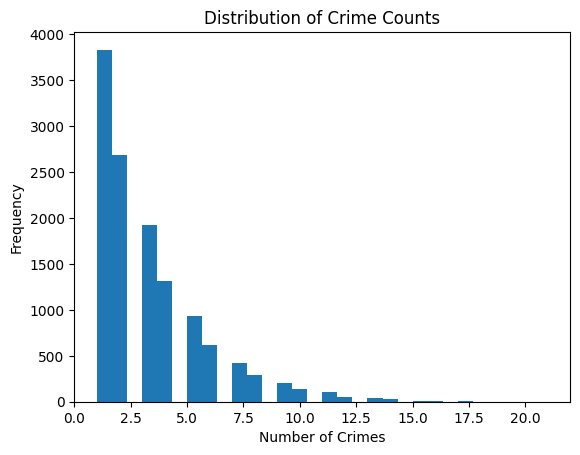

In [17]:
import matplotlib.pyplot as plt

# This Data Visualization to find where the hightest number of data is present in range.

# Check the distribution of Target var [Crime Count]
print(df_model["Crime Count"].describe())

plt.hist(df_model["Crime Count"], bins=30)
plt.title("Distribution of Crime Counts")
plt.xlabel("Number of Crimes")
plt.ylabel("Frequency")
plt.show()

Augumented Data

In [18]:
# Increasing the size of lower data points to make prediction more general 
high_crime_data = df_model[df_model["Crime Count"] > 4]

augmented_data = pd.concat(
    [df_model, high_crime_data, high_crime_data, high_crime_data]
)

X = augmented_data[["State", "Year", "Month", "Crime Description", "Cluster_ID"]]
y = augmented_data["Crime Count"]

print(f"Original Data Size: {len(df_model)}")
print(f"New Augmented Size: {len(augmented_data)}")

Original Data Size: 12609
New Augmented Size: 21168


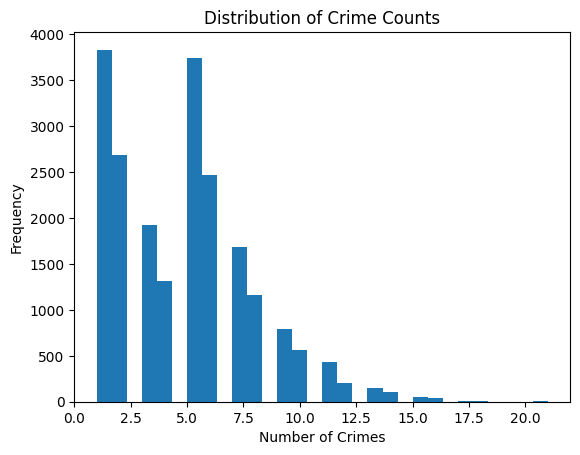

In [19]:
import matplotlib.pyplot as plt

plt.hist(augmented_data['Crime Count'],bins=30)
plt.title("Distribution of Crime Counts")
plt.xlabel("Number of Crimes")
plt.ylabel("Frequency")
plt.show()

Trainer SVR - SUPPORT VECTOR REGRESSION (For Prediction)


In [20]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Preparing Data
cols_to_use = [
    "State",
    "Year",
    "Month",
    "Crime Description",
    "Cluster_ID",
    "Crime Count",
]
df_model = augmented_data.dropna(subset=cols_to_use)

X = df_model[["State", "Year", "Month", "Crime Description", "Cluster_ID"]]
y = df_model["Crime Count"]

# Scale and Train Data
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

svr = SVR(kernel="rbf", C=100, gamma="auto", epsilon=0.1)
svr.fit(X_train, y_train)

print(f"SVM Training Complete. Training Score: {svr.score(X_train, y_train):.2f}")

SVM Training Complete. Training Score: 0.60


Prediction Testing

In [21]:
state_cluster_map = (
    df_with_cluster.groupby("State")["Cluster_ID"].agg(lambda x: x.mode()[0]).to_dict()
)


def get_estimated_cluster(encoded_state_id):
    # Returns the most common cluster for this state
    return state_cluster_map.get(encoded_state_id, 0)

In [22]:
def predict_state_crimes_svm(state_name, year, month):
    results = []

    # Check State
    try:
        state_id = state_encoder.transform([state_name])[0]
    except ValueError:
        return pd.DataFrame([{"Error": "State not found"}])

    # Get Cluster
    cluster_id = get_estimated_cluster(state_id)
    all_crimes = crime_encoder.classes_

    # Prepare batch input
    input_rows = []
    crime_names = []

    for crime in all_crimes:
        crime_id = crime_encoder.transform([crime])[0]
        # match training order: State, Year, Month, Crime Description, Cluster_ID
        input_rows.append([state_id, year, month, crime_id, cluster_id])
        crime_names.append(crime)

    # Convert to DF
    input_df = pd.DataFrame(
        input_rows,
        columns=["State", "Year", "Month", "Crime Description", "Cluster_ID"],
    )

    input_scaled = scaler_X.transform(input_df)

    # Predict
    predictions = svr.predict(input_scaled)

    for i, val in enumerate(predictions):
        final_val = int(round(val))
        results.append(
            {
                "Crime Type": crime_names[i],
                "Predicted Count": max(0, final_val),  # No negative crimes
            }
        )

    return pd.DataFrame(results)


# --- TEST ---
print("\n--- Prediction for Andhra Pradesh (May 2025) ---")
# Make sure to use a State Name that exists in your CSV (Case Sensitive)
print(predict_state_crimes_svm("Andhra Pradesh", 2025, 2).head(10))


--- Prediction for Andhra Pradesh (May 2025) ---
          Crime Type  Predicted Count
0              ARSON                1
1            ASSAULT                1
2           BURGLARY                1
3     COUNTERFEITING                1
4         CYBERCRIME                1
5  DOMESTIC VIOLENCE                1
6       DRUG OFFENSE                2
7          EXTORTION                2
8    FIREARM OFFENSE                2
9              FRAUD                2


In [23]:
# import numpy as np


# def predict_state_crimes(state_name, year, month):
#     results = []

#     # 1. Encode the State Name
#     try:
#         state_id = state_encoder.transform([state_name])[0]
#     except ValueError:
#         return "Error: State not found in training data"

#     # 2. Get the likely Cluster ID for this state
#     cluster_id = get_estimated_cluster(state_id)

#     # 3. Loop through ALL known crime types
#     all_crimes = crime_encoder.classes_  # e.g., ['Theft', 'Assault', 'Fraud'...]

#     for crime_name in all_crimes:
#         crime_id = crime_encoder.transform([crime_name])[0]

#         # Prepare Input Vector: [State, Year, Month, Crime Description, Cluster_ID]
#         # Must match the order of X in your training:
#         # ["State", "Year", "Month", "Crime Description", "Cluster_ID"]
#         input_row = pd.DataFrame(
#             [
#                 {
#                     "State": state_id,
#                     "Year": year,
#                     "Month": month,
#                     "Crime Description": crime_id,
#                     "Cluster_ID": cluster_id,
#                 }
#             ]
#         )

#         # Predict
#         pred_count = svr.predict(input_row)[0]

#         # Clean up negative predictions (Regression can sometimes give -1.5)
#         pred_count = max(0, round(pred_count))

#         results.append({"Crime Type": crime_name, "Predicted Count": int(pred_count)})

#     return pd.DataFrame(results)


# # --- TEST IT ---
# # This dataframe is what you will show in your Frontend Table
# print("\n--- Prediction for Andhra Pradesh (May 2025) ---")
# table_output = predict_state_crimes(
#     "Andhra Pradesh", 2025, 5
# )  # Use exact state name from your CSV
# print(table_output.head(50))